# Electron Microscopy Particle Segmentation

## Introduction

Electron microscopy enables high-resolution imaging of micro- and nano-scale structures, making it a powerful tool for quantitative material characterisation. A key requirement in many applications is the ability to identify and isolate individual structures, such as particles or fibres, from the background. This process, known as segmentation, enables measurement of critical properties including size, shape, and spatial distribution.

Manual segmentation is slow, subjective, and impractical at industrial scale. Machine learning, particularly convolutional neural networks (CNNs), provides a scalable alternative by learning to automatically infer segmentation masks directly from raw microscopy images.

In this notebook, we use the **Electron Microscopy Particle Segmentation dataset from Kaggle** to develop and evaluate a deep learning model capable of identifying individual particles.

Although this dataset focuses on particulate materials, the underlying computer vision problem is directly analogous to **textile fibre characterisation**. In both cases, the objective is to:

- Identify individual microscopic structures within a complex image
- Separate overlapping or touching objects
- Extract quantitative geometric features such as length, diameter, and morphology
- Enable automated statistical analysis of the material population

In textile recycling and fibre characterisation systems, segmentation is a foundational step that enables downstream analysis such as fibre size distribution estimation, material classification, and process suitability assessment. The same segmentation architectures used for particle detection can therefore be directly adapted to fibre imagery, including optical microscopy and scanning electron microscopy (SEM) of textile feedstocks.

This notebook therefore serves not only as an implementation of particle segmentation, but also as a technical precursor to automated fibre characterisation systems.

## Dataset Overview

The dataset consists of paired samples:

- **Input image** – Electron microscopy image containing multiple particles
- **Segmentation map** – Ground truth mask identifying particle pixels

Each segmentation map provides pixel-level supervision, enabling supervised learning of particle boundaries.

From a fibre characterisation perspective, these segmentation maps are equivalent to fibre masks, which would enable measurement of properties such as:

- Fibre diameter
- Fibre length
- Aspect ratio
- Size distribution

## Approach Overview

The workflow implemented in this notebook follows these stages:

1. Dataset loading and preprocessing
2. Train / validation split
3. Model definition
4. Training loop
5. Model evaluation and visualisation
6. Performance analysis

## Relevance to Automated Fibre Characterisation

Automated segmentation is a critical enabling technology for scalable fibre characterisation systems. By replacing manual analysis with machine learning, it becomes possible to:

- Process large volumes of microscopy data
- Produce objective and reproducible measurements
- Enable real-time material assessment in industrial pipelines

The methods developed here can therefore be directly extended to textile fibre datasets, supporting applications in recycling, material quality control, and feedstock optimisation.

## Expected Outcome

By the end of this notebook, the trained model should be able to:

- Accurately identify individual particles in microscopy images
- Produce segmentation maps suitable for quantitative analysis
- Demonstrate techniques transferable to textile fibre segmentation problems

---


You only need to set your `data/images` and `data/segmaps` folders.


In [3]:
# Imports (boring)

import os
from pathlib import Path
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from PIL import Image

import torchvision.transforms.functional as TF
from torchvision.models.segmentation import deeplabv3_resnet50
from torchvision.models.segmentation.deeplabv3 import DeepLabHead
from torchvision.transforms import InterpolationMode

from sklearn.metrics import f1_score

from scipy import ndimage

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


In [4]:
# Set dataset paths

PROJECT_ROOT = Path.cwd()
IMAGES_PATH = PROJECT_ROOT / "seg_par" / "data" / "images"
SEGMAPS_PATH = PROJECT_ROOT / "seg_par" / "data" / "segmaps"

print(IMAGES_PATH.resolve())
print(SEGMAPS_PATH.resolve())


C:\Users\joshp\PycharmProjects\fab_mat_char\seg_par\data\images
C:\Users\joshp\PycharmProjects\fab_mat_char\seg_par\data\segmaps


In [5]:
class TorchSegDataset(Dataset):
    def __init__(self, data_dict, size=(256,256)):
        self.keys = list(data_dict.keys())
        self.data = data_dict
        self.size = size

    def __len__(self):
        return len(self.keys)

    def __getitem__(self, idx):
        stem = self.keys[idx]
        image, segmap = self.data[stem]

        image = TF.resize(image, self.size, interpolation=InterpolationMode.BILINEAR)
        segmap = TF.resize(segmap, self.size, interpolation=InterpolationMode.NEAREST)

        image = TF.to_tensor(image)  # [3,H,W], float32 0..1

        seg_np = np.array(segmap, dtype=np.int64)  # [H,W], instance IDs
        # Convert instance IDs -> binary foreground mask
        seg_np = (seg_np > 0).astype(np.int64)

        mask = torch.from_numpy(seg_np).long()     # [H,W], values 0 or 1

        return image, mask

class PSegDataset:
    def __init__(self):
        self.total_dataset = self._fetch_dataset()
        self.train, self.val = self._train_val_split()

        self.train_ds = TorchSegDataset(self.train)
        self.val_ds   = TorchSegDataset(self.val)

    def _fetch_dataset(self):

        ret_val = {}
        for img_path in IMAGES_PATH.iterdir():
            if not img_path.is_file():
                continue

            stem = img_path.stem
            seg_path = SEGMAPS_PATH / f"{stem}.png"

            image = Image.open(img_path).convert("RGB")
            segmap = Image.open(seg_path).convert("L")

            ret_val[stem] = [image, segmap]

        return ret_val

    def _train_val_split(self):
        split_idx = int(len(self.total_dataset) * 0.8)

        keys = list(self.total_dataset.keys())

        train_keys = keys[:split_idx]
        val_keys = keys[split_idx:]

        train = {k: self.total_dataset[k] for k in train_keys}
        val = {k: self.total_dataset[k] for k in val_keys}

        return train, val


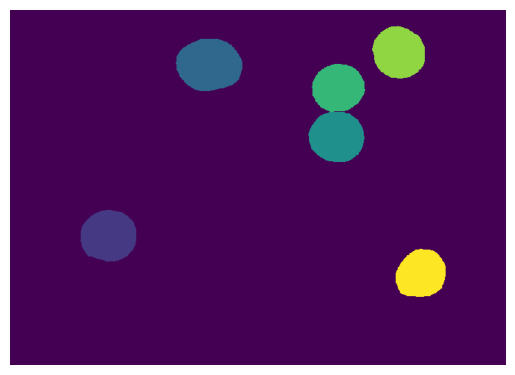

In [6]:
    dataset = PSegDataset()

    # Display Example:
    subject = "f28b702df5"
    plt.imshow(dataset.total_dataset[subject][1])
    plt.axis("off")
    plt.show()

    train_loader = DataLoader(
        dataset.train_ds,
        batch_size=8,
        shuffle=True,
        num_workers=0,
        pin_memory=True
    )
    val_loader = DataLoader(
        dataset.val_ds,
        batch_size=8,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

In [10]:
# Model

def build_deeplab(num_classes=2):
    model = deeplabv3_resnet50(weights="DEFAULT")  # pretrained backbone
    # Replace classifier head to output num_classes
    model.classifier[-1] = nn.Conv2d(256, num_classes, kernel_size=1)
    return model

model = build_deeplab().to(device)


In [8]:
# Loss

def dice_loss_from_logits(logits, targets, eps=1e-6):
    probs = torch.softmax(logits, dim=1)[:, 1]      # foreground prob [B,H,W]
    targets_f = targets.float()

    intersection = (probs * targets_f).sum(dim=(1,2))
    union = probs.sum(dim=(1,2)) + targets_f.sum(dim=(1,2))
    dice = (2 * intersection + eps) / (union + eps)
    return 1 - dice.mean()


In [63]:
# Training

optimizer = optim.Adam(model.parameters(), lr=1e-4)
ce = nn.CrossEntropyLoss()

def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    ce = nn.CrossEntropyLoss()

    for imgs, masks in loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        out = model(imgs)["out"]
        loss = ce(out, masks) + 0.5 * dice_loss_from_logits(out, masks)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)

    return total_loss / len(loader.dataset)


In [ ]:
# Train example

@torch.no_grad()
def eval_epoch(model, loader, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_targs = []

    ce = nn.CrossEntropyLoss()

    for imgs, masks in loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        out = model(imgs)["out"]  # [B,2,H,W]
        loss = ce(out, masks) + 0.5 * dice_loss_from_logits(out, masks)

        total_loss += loss.item() * imgs.size(0)

        pred = out.argmax(dim=1)  # [B,H,W]
        all_preds.append(pred.flatten().cpu())
        all_targs.append(masks.flatten().cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_targs = torch.cat(all_targs).numpy()
    f1 = f1_score(all_targs, all_preds, average="binary", zero_division=0)

    return total_loss / len(loader.dataset), f1

best_f1 = -1.0
for epoch in range(1, 31):
    tr_loss = train_epoch(model, train_loader, optimizer, device)
    va_loss, va_f1 = eval_epoch(model, val_loader, device)

    print(f"Epoch {epoch:02d} | train_loss={tr_loss:.4f} | val_loss={va_loss:.4f} | val_f1={va_f1:.4f}")

    if va_f1 > best_f1:
        best_f1 = va_f1
        torch.save(model.state_dict(), "best_deeplab_particles.pt")
        print("  saved best model")


C:\Users\joshp\AppData\Local\Temp\ipykernel_46988\3767687294.py:96: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_deeplab_particles.pt

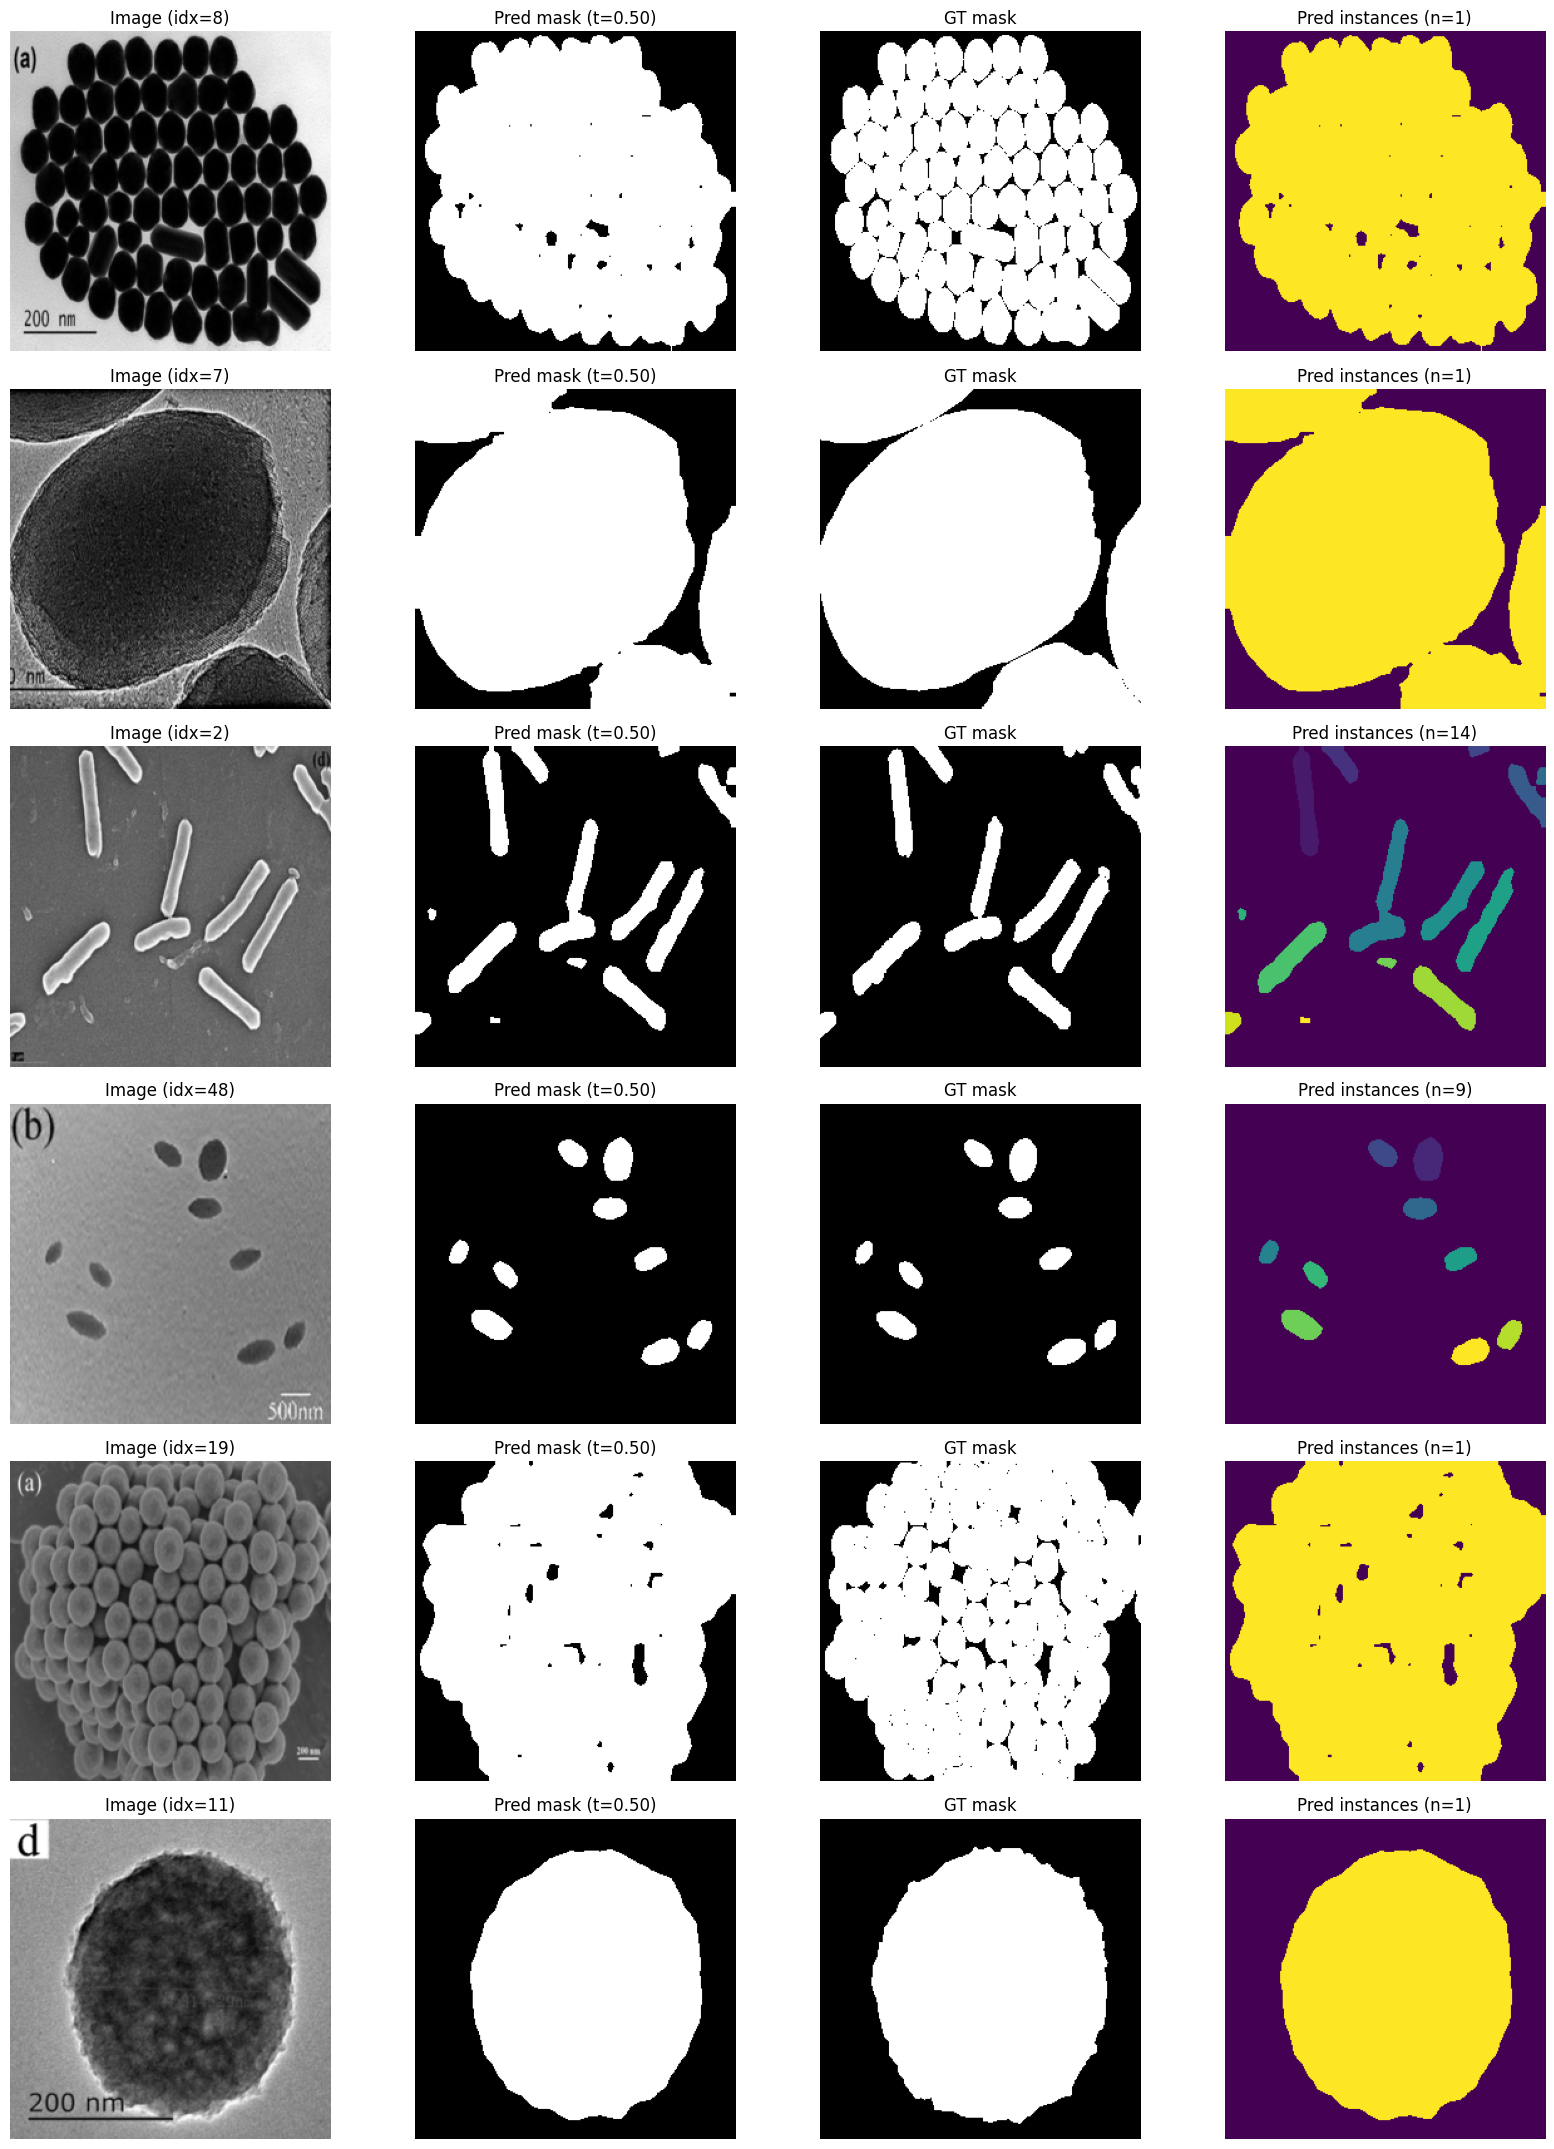

In [11]:
# Visualisation

@torch.no_grad()
def visualise_val_predictions(
    model,
    val_dataset,
    device,
    n=6,
    thresh=0.5,
    seed=0,
    show_instances=True,
):
    """
    Visualise model performance on the validation dataset.

    Shows for each sample:
      - RGB image
      - Predicted binary mask (foreground prob > thresh)
      - Ground-truth binary mask
      - (Optional) Predicted instance labels via connected components

    Parameters
    ----------
    model : torch.nn.Module
        Segmentation model returning dict with key "out" -> logits [B,2,H,W].
    val_dataset : torch.utils.data.Dataset
        Returns (image, mask) where image is [3,H,W] float, mask is [H,W] long (0/1).
    device : torch.device
    n : int
        Number of validation samples to display.
    thresh : float
        Threshold on foreground probability.
    seed : int
        Random seed for reproducible sampling.
    show_instances : bool
        If True, add an "Instances" panel showing connected-component labels.
    """
    model.eval()

    rng = random.Random(seed)
    idxs = list(range(len(val_dataset)))
    rng.shuffle(idxs)
    idxs = idxs[: min(n, len(idxs))]

    cols = 4 if show_instances else 3
    rows = len(idxs)

    fig, axes = plt.subplots(rows, cols, figsize=(4.2 * cols, 3.6 * rows))
    if rows == 1:
        axes = np.expand_dims(axes, axis=0)  # make [rows, cols]

    for r, idx in enumerate(idxs):
        img, gt = val_dataset[idx]  # img: [3,H,W], gt: [H,W]
        x = img.unsqueeze(0).to(device)  # [1,3,H,W]

        out = model(x)["out"]  # [1,2,H,W] logits
        prob_fg = torch.softmax(out, dim=1)[:, 1]  # [1,H,W]
        pred = (prob_fg[0] > thresh).to(torch.uint8).cpu().numpy()  # [H,W] 0/1

        # GT to numpy
        gt_np = gt.cpu().numpy().astype(np.uint8)  # [H,W] 0/1

        # Image to numpy for plotting
        img_np = img.permute(1, 2, 0).cpu().numpy()  # [H,W,3]

        # --- Panel 1: RGB image ---
        ax = axes[r, 0]
        ax.imshow(img_np)
        ax.set_title(f"Image (idx={idx})")
        ax.axis("off")

        # --- Panel 2: Pred mask ---
        ax = axes[r, 1]
        ax.imshow(pred, cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"Pred mask (t={thresh:.2f})")
        ax.axis("off")

        # --- Panel 3: GT mask ---
        ax = axes[r, 2]
        ax.imshow(gt_np, cmap="gray", vmin=0, vmax=1)
        ax.set_title("GT mask")
        ax.axis("off")

        # --- Optional Panel 4: Pred instances via connected components ---
        if show_instances:
            labels, num = ndimage.label(pred)  # 0..num
            ax = axes[r, 3]
            ax.imshow(labels, cmap="viridis")
            ax.set_title(f"Pred instances (n={num})")
            ax.axis("off")

    plt.tight_layout()
    plt.show()

model = build_deeplab(num_classes=2).to(device)
model.load_state_dict(torch.load("best_deeplab_particles.pt", map_location=device))

dataset = PSegDataset()
visualise_val_predictions(
    model=model,
    val_dataset=dataset.val_ds,
    device=device,
    n=6,
    thresh=0.5,
    show_instances=True
)
